<a href="https://www.kaggle.com/code/omborse771924/inzaghi-fashion-ai-dataset-eda?scriptVersionId=331899484" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/wardaadann/inzaghi-ai-castle/fashion_dataset_complete.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/wardaadann/inzaghi-ai-castle/fashion_dataset_complete.csv')

In [3]:
df.head()

,user_id,session_id,timestamp,gender,age_group,body_type,skin_tone,height,style_preference,budget_level,...,saves,tryon_count,purchased,embedding_1,embedding_2,embedding_3,month,total_score,recommendation_priority,outfit_description
0,INZ_000000,c807fc10dcbc,2023-04-23,Non-binary,45-54,Apple,Light,"6'0""-6'2""",Minimalist,Premium,...,9,19,0,-0.2158,-0.5682,2.1110,4,0.646,High,Minimalist T-shirt in Navy - Perfect for Formal
1,INZ_000001,1d95c3f54b1e,2023-06-23,Gender-fluid,45-54,Hourglass,Tan,"6'0""-6'2""",Romantic,Mid-range,...,17,7,0,-1.3490,-0.2519,0.6696,6,0.720,High,Romantic Shorts in Gray - Perfect for Vacation
2,INZ_000002,51f132eee770,2023-11-22,Female,35-44,Athletic,Dark,"6'0""-6'2""",Bohemian,Mid-range,...,11,8,0,-0.1628,0.1518,0.3025,11,0.760,High,Bohemian Top in White - Perfect for Brunch
3,INZ_000003,6b75503a364f,2023-01-24,Non-binary,18-24,Inverted Triangle,Dark,"5'6""-5'8""",Streetwear,Luxury,...,7,11,0,0.7484,-1.3508,0.8619,1,0.581,Medium,Streetwear Jeans in Navy - Perfect for Formal
4,INZ_000004,94ec485a2997,2023-06-07,Non-binary,25-34,Rectangle,Dark,"5'6""-5'8""",Edgy,Premium,...,15,11,0,0.3239,-0.6195,1.8628,6,0.664,High,Edgy Jeans in Beige - Perfect for Wedding


In [4]:
df.tail()

,user_id,session_id,timestamp,gender,age_group,body_type,skin_tone,height,style_preference,budget_level,...,saves,tryon_count,purchased,embedding_1,embedding_2,embedding_3,month,total_score,recommendation_priority,outfit_description
10495,INZ_010495,7552d926d280,2023-05-22,Non-binary,55+,Inverted Triangle,Light,"5'9""-5'11""",Streetwear,Luxury,...,8,7,0,-0.9260,-3.5313,0.5991,5,0.594,Medium,Streetwear Pants in Black - Perfect for Casual
10496,INZ_010496,f095483fba8c,2023-10-24,Gender-fluid,45-54,Hourglass,Fair,"5'3""-5'5""",Minimalist,Luxury,...,12,10,0,1.2025,-0.4055,-1.0266,10,0.587,Medium,Minimalist Jacket in Yellow - Perfect for Party
10497,INZ_010497,b13942f7ce6d,2023-08-19,Gender-fluid,55+,Apple,Light,"5'3""-5'5""",Edgy,Premium,...,10,4,0,-1.6801,-0.4680,-1.0694,8,0.573,Medium,Edgy Jeans in Navy - Perfect for Gym
10498,INZ_010498,70c929043745,2023-05-26,Gender-fluid,25-34,Hourglass,Tan,"5'3""-5'5""",Classic,Budget,...,12,8,0,-0.0226,0.9774,-0.5769,5,0.669,High,Classic Shorts in Green - Perfect for Party
10499,INZ_010499,349457ba6f14,2023-04-26,Male,35-44,Apple,Light,"6'0""-6'2""",Edgy,Mid-range,...,11,11,0,-1.0110,0.2196,0.2064,4,0.402,Medium,Edgy Dress in Black - Perfect for Formal


In [5]:
df.describe()

,price_usd,satisfaction_score,trend_score,comfort_score,sustainability_score,quality_score,fit_score,views,likes,shares,saves,tryon_count,purchased,embedding_1,embedding_2,embedding_3,month,total_score
count,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000
mean,260.421364,0.646624,0.496825,0.651464,0.503853,0.704461,0.749914,100.003429,19.936095,4.994190,10.021905,7.984286,0.153143,0.006185,-0.019805,-0.002212,6.487524,0.624603
std,138.746737,0.201924,0.288083,0.202214,0.289317,0.173814,0.143501,10.058245,4.500311,2.257174,3.139348,2.797111,0.360142,1.005982,0.998068,1.012882,3.453463,0.111665
min,20.170000,0.300000,0.000000,0.300000,0.000000,0.400000,0.500000,68.000000,5.000000,0.000000,1.000000,0.000000,0.000000,-3.811100,-4.070900,-3.871300,1.000000,0.289000
25%,138.705000,0.472000,0.247000,0.478000,0.249000,0.555000,0.625750,93.000000,17.000000,3.000000,8.000000,6.000000,0.000000,-0.671375,-0.687125,-0.692425,3.000000,0.548000
50%,262.110000,0.643000,0.496000,0.648500,0.507000,0.709000,0.750000,100.000000,20.000000,5.000000,10.000000,8.000000,0.000000,-0.003050,-0.022000,-0.002200,7.000000,0.623000
75%,380.840000,0.819000,0.745000,0.828000,0.753000,0.856000,0.874000,107.000000,23.000000,6.000000,12.000000,10.000000,0.000000,0.684275,0.652275,0.680300,10.000000,0.704000
max,499.910000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,142.000000,37.000000,16.000000,25.000000,20.000000,1.000000,4.484400,3.607400,3.506200,12.000000,0.956000


In [6]:
df.isnull

<bound method DataFrame.isnull of           user_id    session_id   timestamp        gender age_group  \
0      INZ_000000  c807fc10dcbc  2023-04-23    Non-binary     45-54   
1      INZ_000001  1d95c3f54b1e  2023-06-23  Gender-fluid     45-54   
2      INZ_000002  51f132eee770  2023-11-22        Female     35-44   
3      INZ_000003  6b75503a364f  2023-01-24    Non-binary     18-24   
4      INZ_000004  94ec485a2997  2023-06-07    Non-binary     25-34   
...           ...           ...         ...           ...       ...   
10495  INZ_010495  7552d926d280  2023-05-22    Non-binary       55+   
10496  INZ_010496  f095483fba8c  2023-10-24  Gender-fluid     45-54   
10497  INZ_010497  b13942f7ce6d  2023-08-19  Gender-fluid       55+   
10498  INZ_010498  70c929043745  2023-05-26  Gender-fluid     25-34   
10499  INZ_010499  349457ba6f14  2023-04-26          Male     35-44   

               body_type skin_tone      height style_preference budget_level  \
0                  Apple     Ligh

In [7]:
df.isnull().sum()

user_id                    0
session_id                 0
timestamp                  0
gender                     0
age_group                  0
body_type                  0
skin_tone                  0
height                     0
style_preference           0
budget_level               0
preferred_brand            0
clothing_type              0
fabric                     0
primary_color              0
pattern                    0
occasion                   0
mood                       0
season                     0
weather                    0
price_usd                  0
satisfaction_score         0
trend_score                0
comfort_score              0
sustainability_score       0
quality_score              0
fit_score                  0
views                      0
likes                      0
shares                     0
saves                      0
tryon_count                0
purchased                  0
embedding_1                0
embedding_2                0
embedding_3   

In [8]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10495    False
10496    False
10497    False
10498    False
10499    False
Length: 10500, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['user_id', 'session_id', 'timestamp', 'gender', 'age_group',
       'body_type', 'skin_tone', 'height', 'style_preference', 'budget_level',
       'preferred_brand', 'clothing_type', 'fabric', 'primary_color',
       'pattern', 'occasion', 'mood', 'season', 'weather', 'price_usd',
       'satisfaction_score', 'trend_score', 'comfort_score',
       'sustainability_score', 'quality_score', 'fit_score', 'views', 'likes',
       'shares', 'saves', 'tryon_count', 'purchased', 'embedding_1',
       'embedding_2', 'embedding_3', 'month', 'total_score',
       'recommendation_priority', 'outfit_description'],
      dtype='object')

## EDA

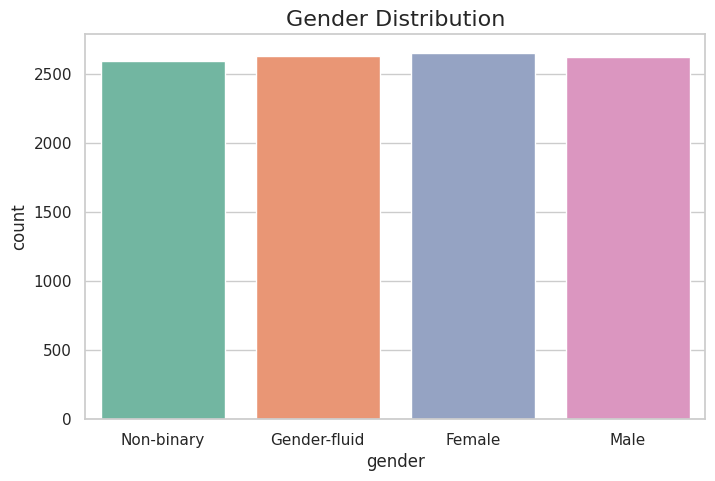

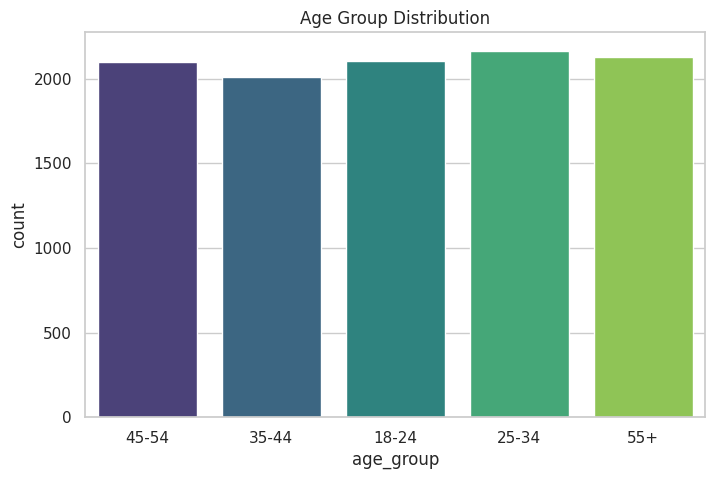

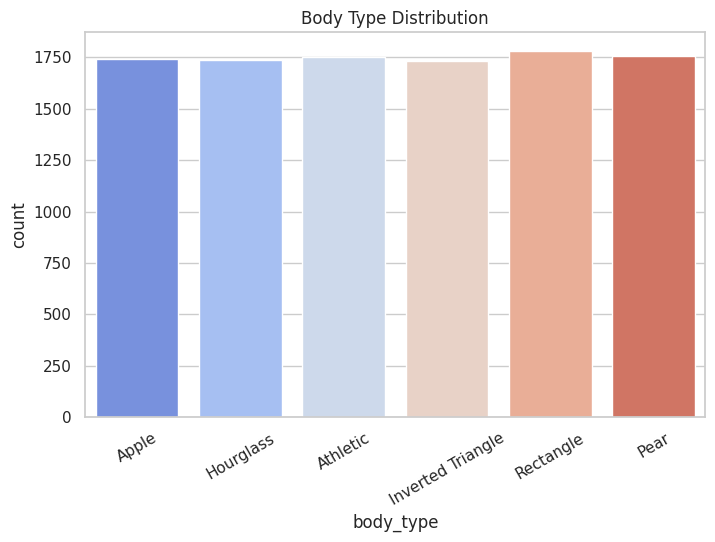

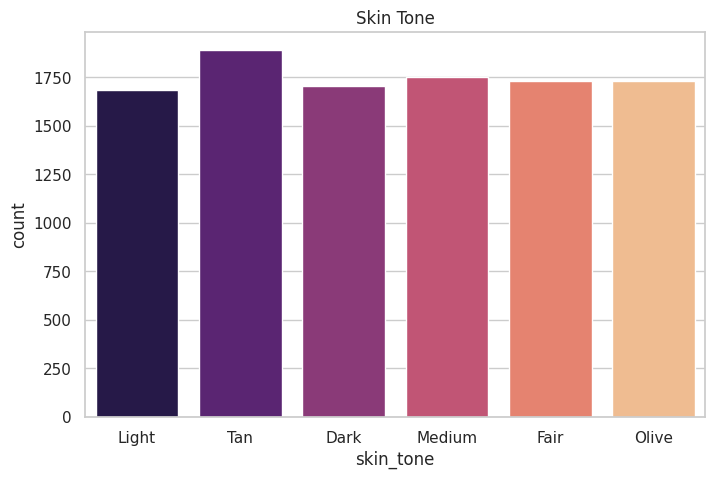

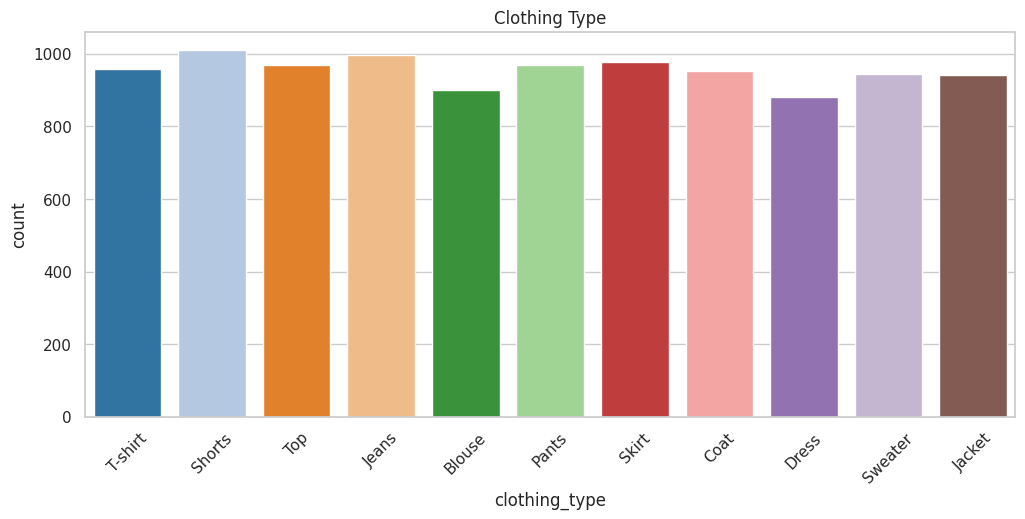

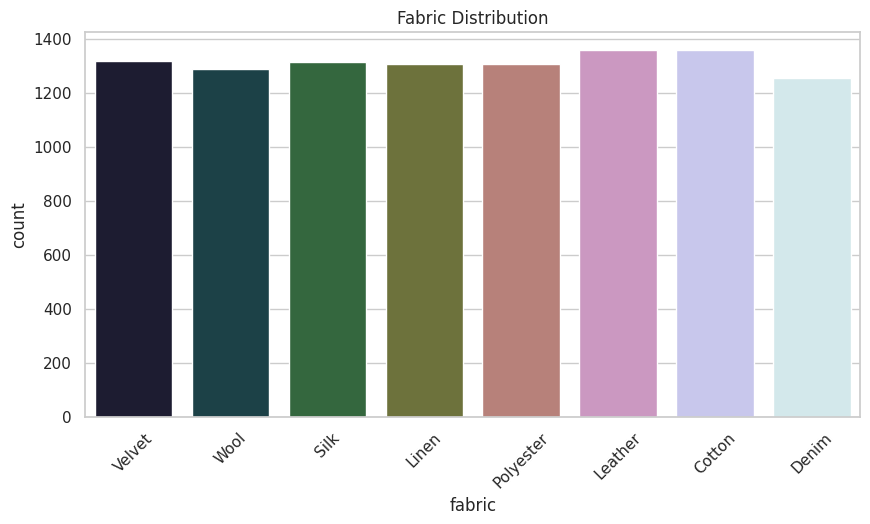

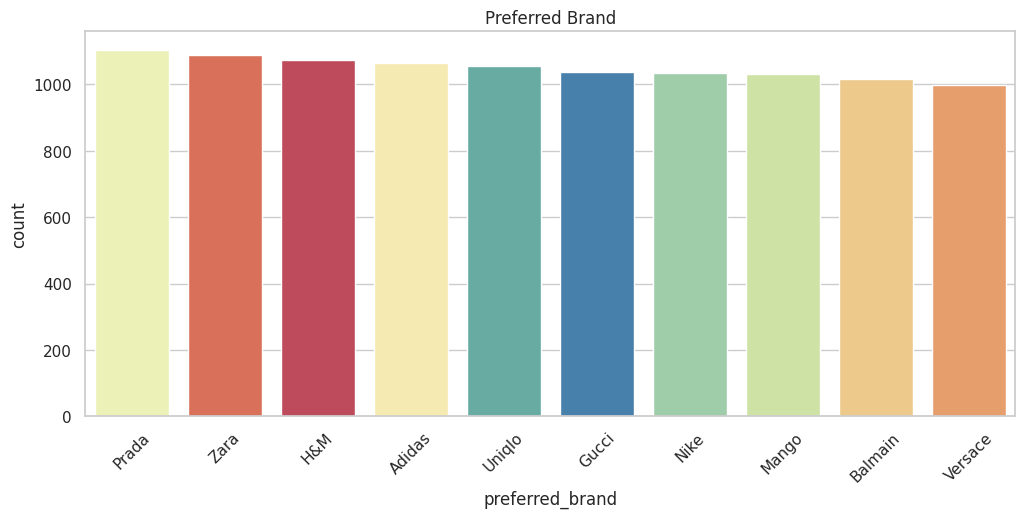

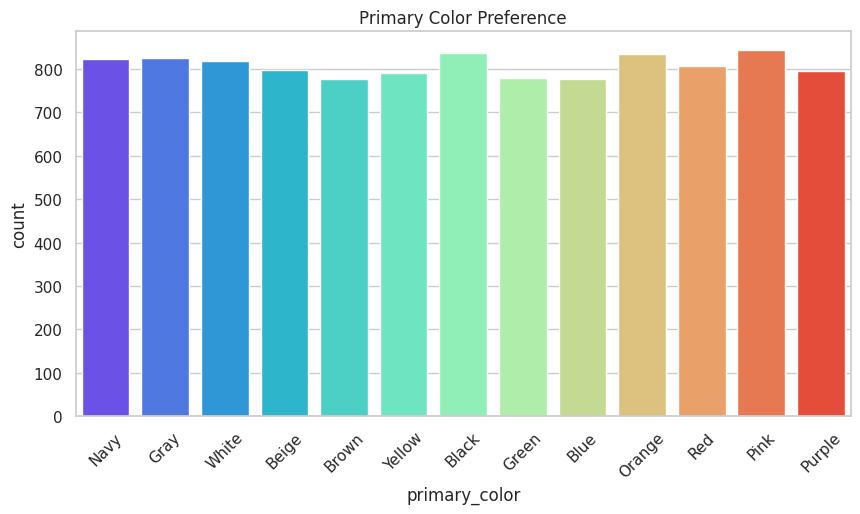

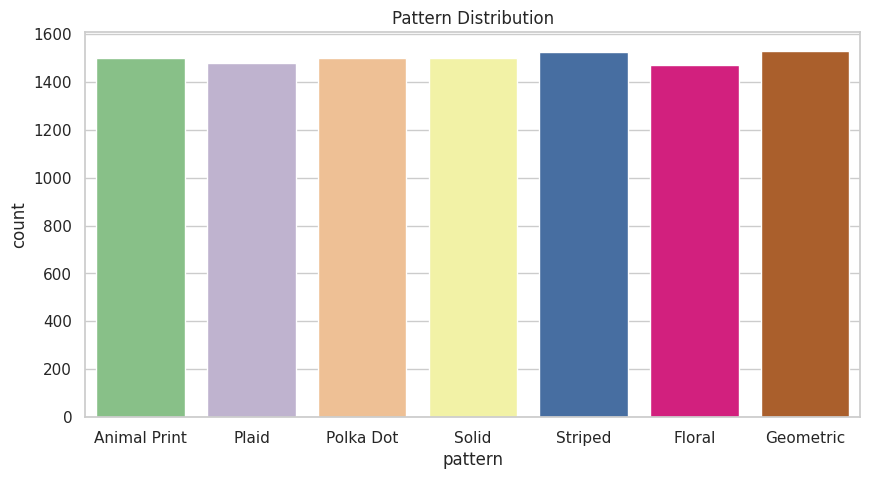

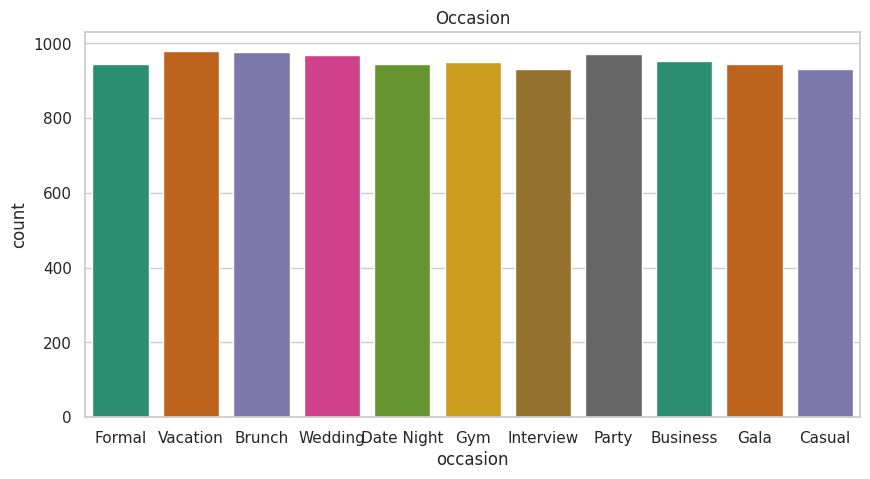

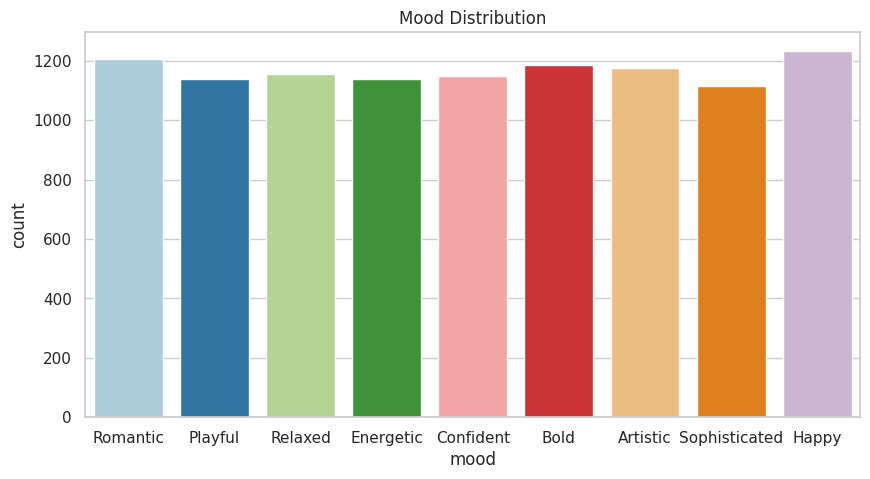

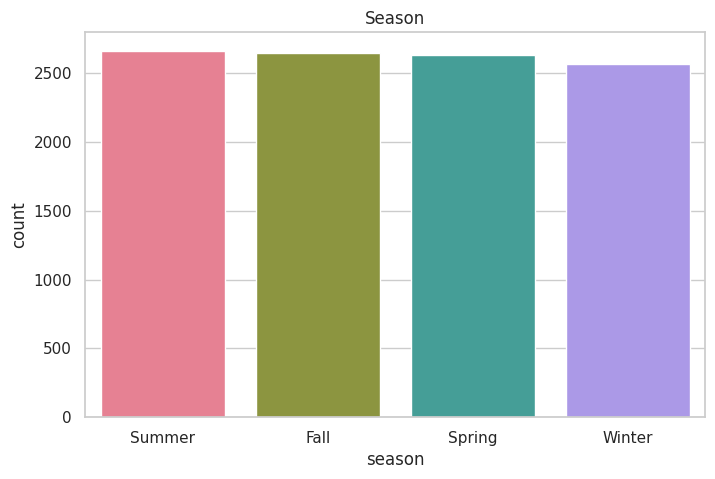

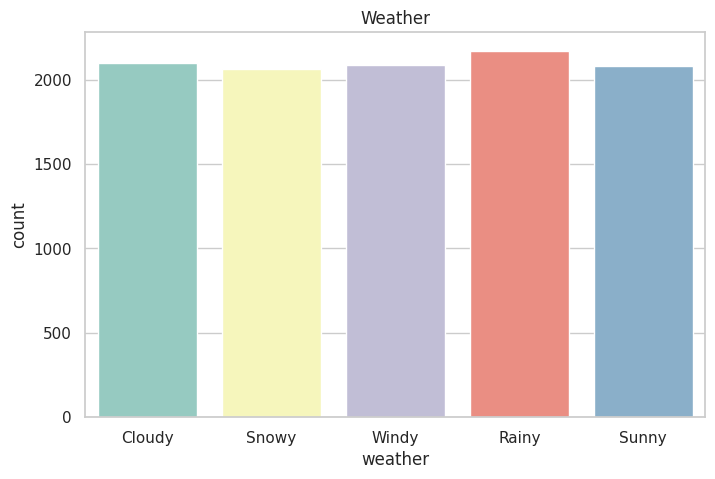

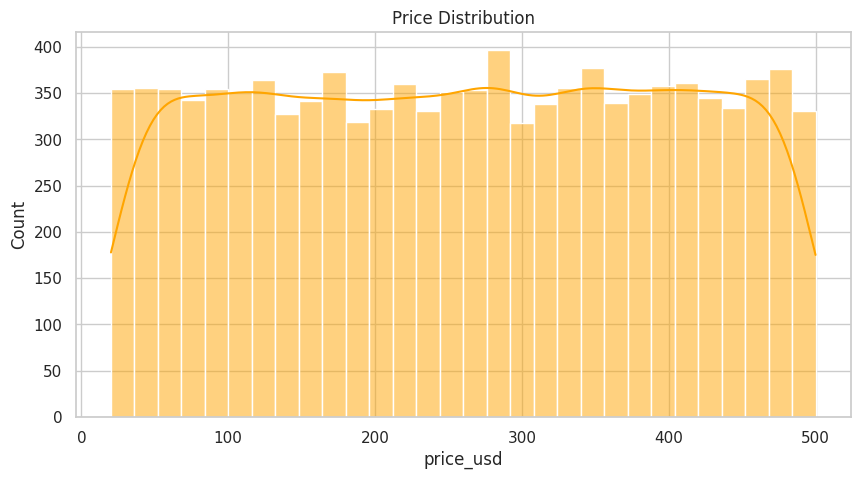

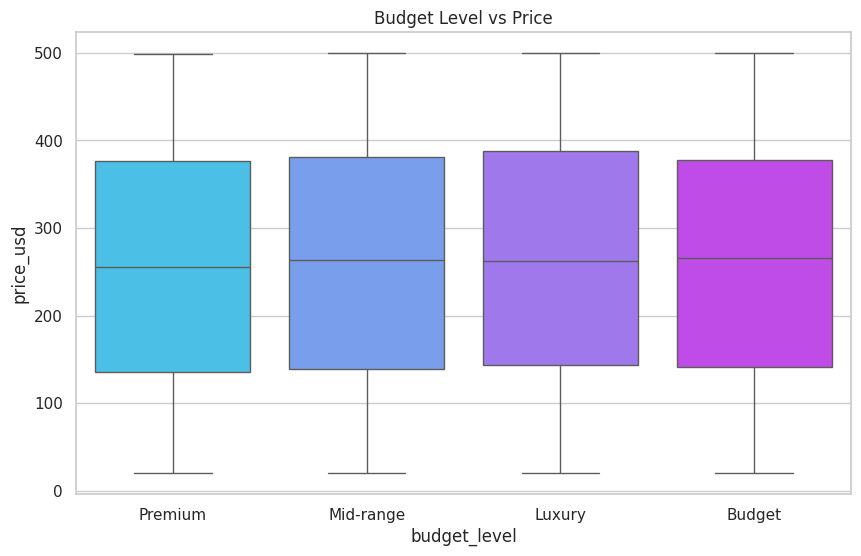

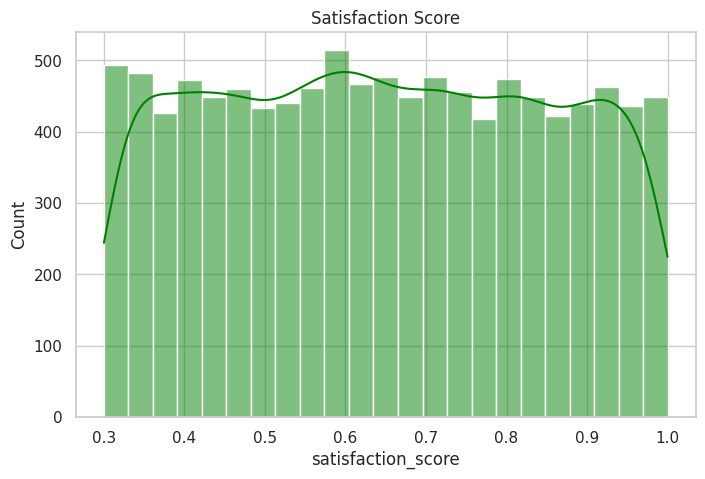

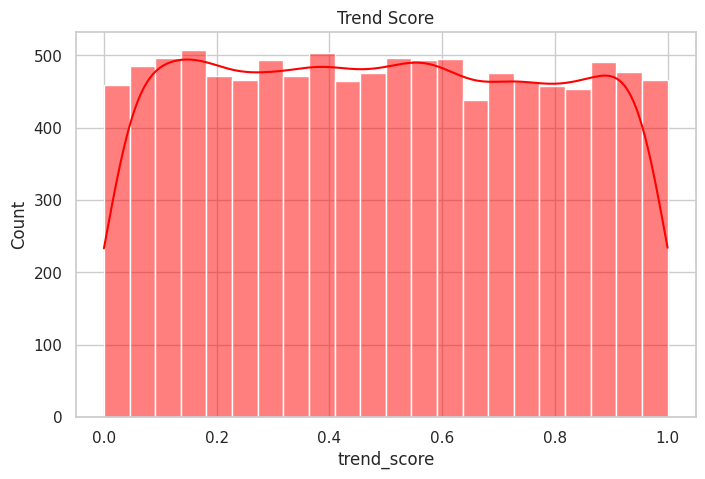

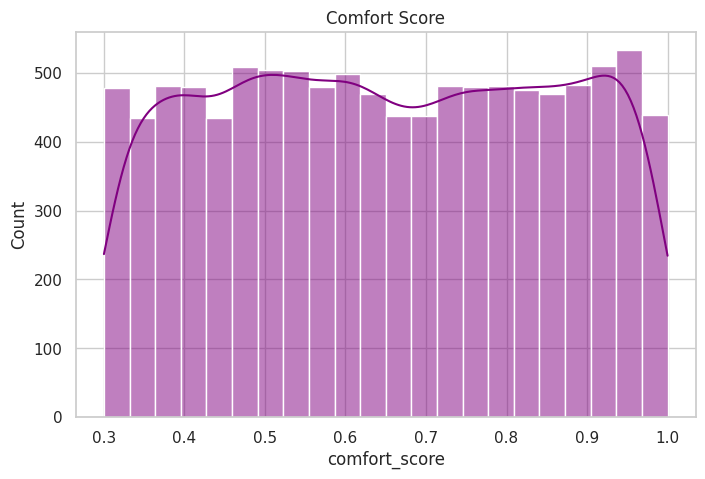

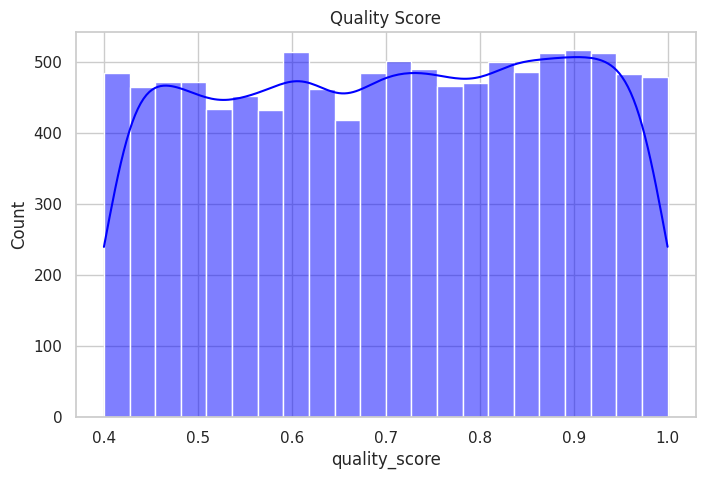

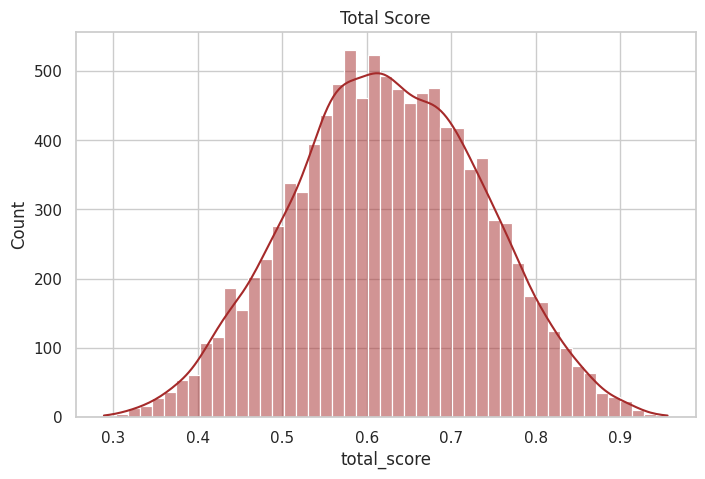

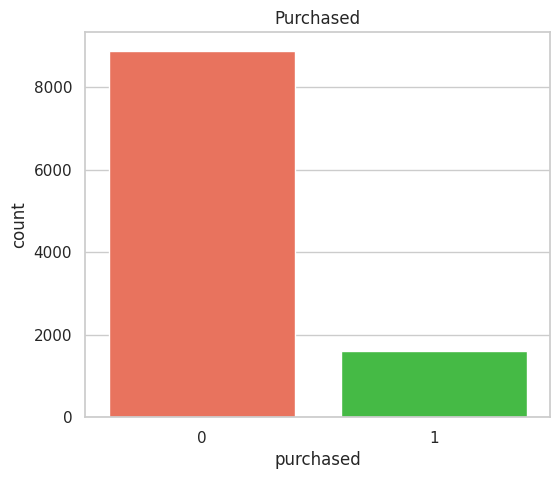

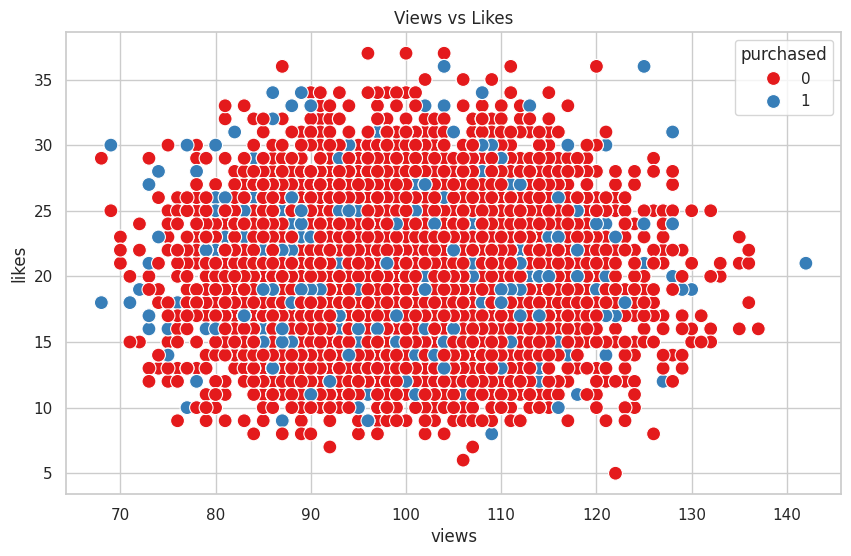

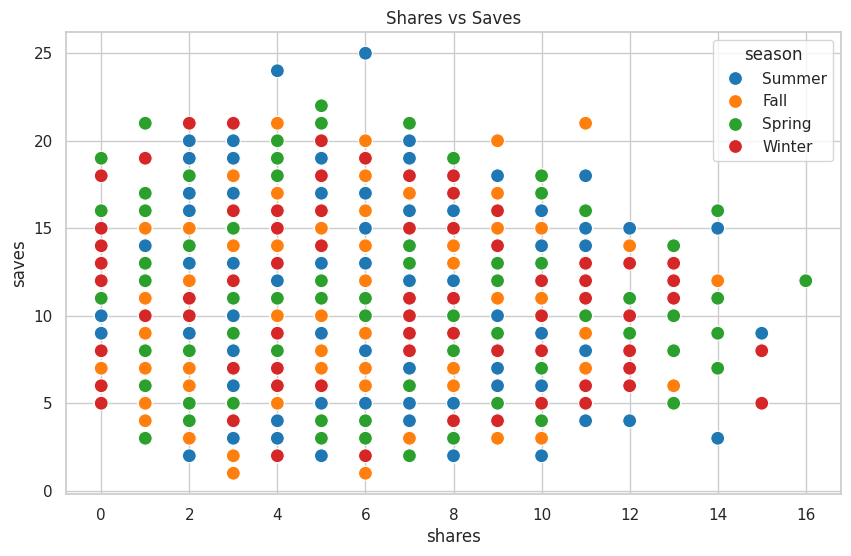

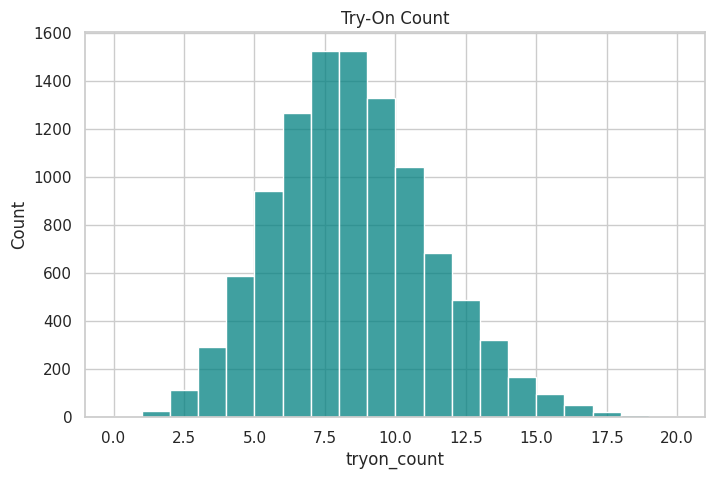

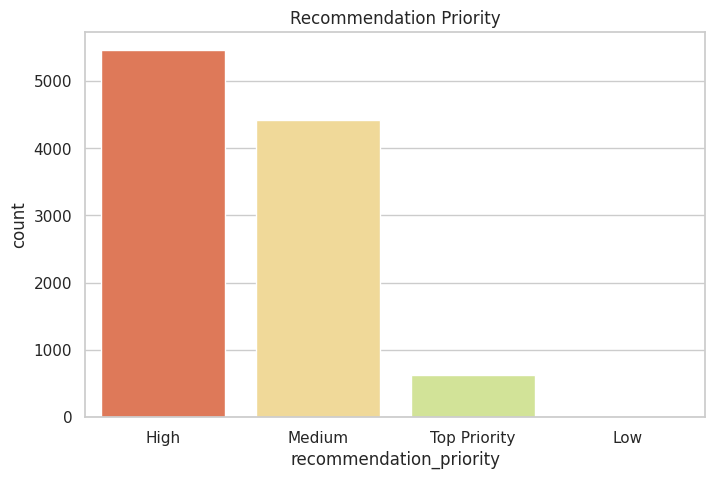

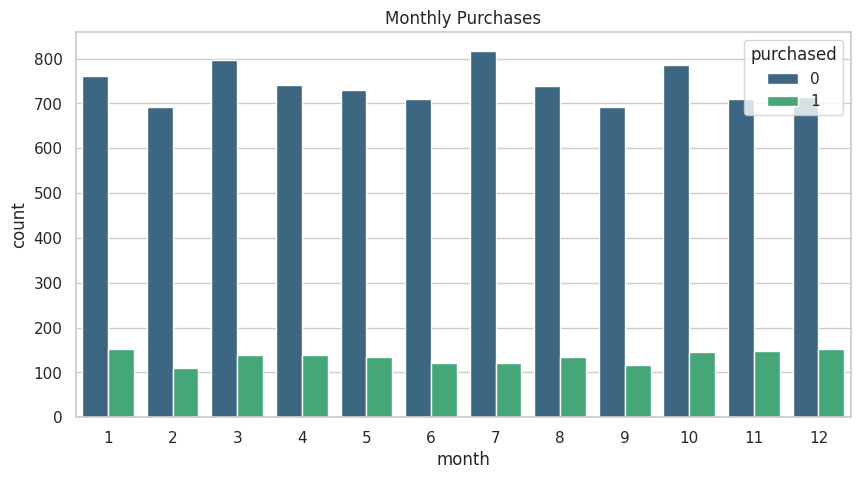

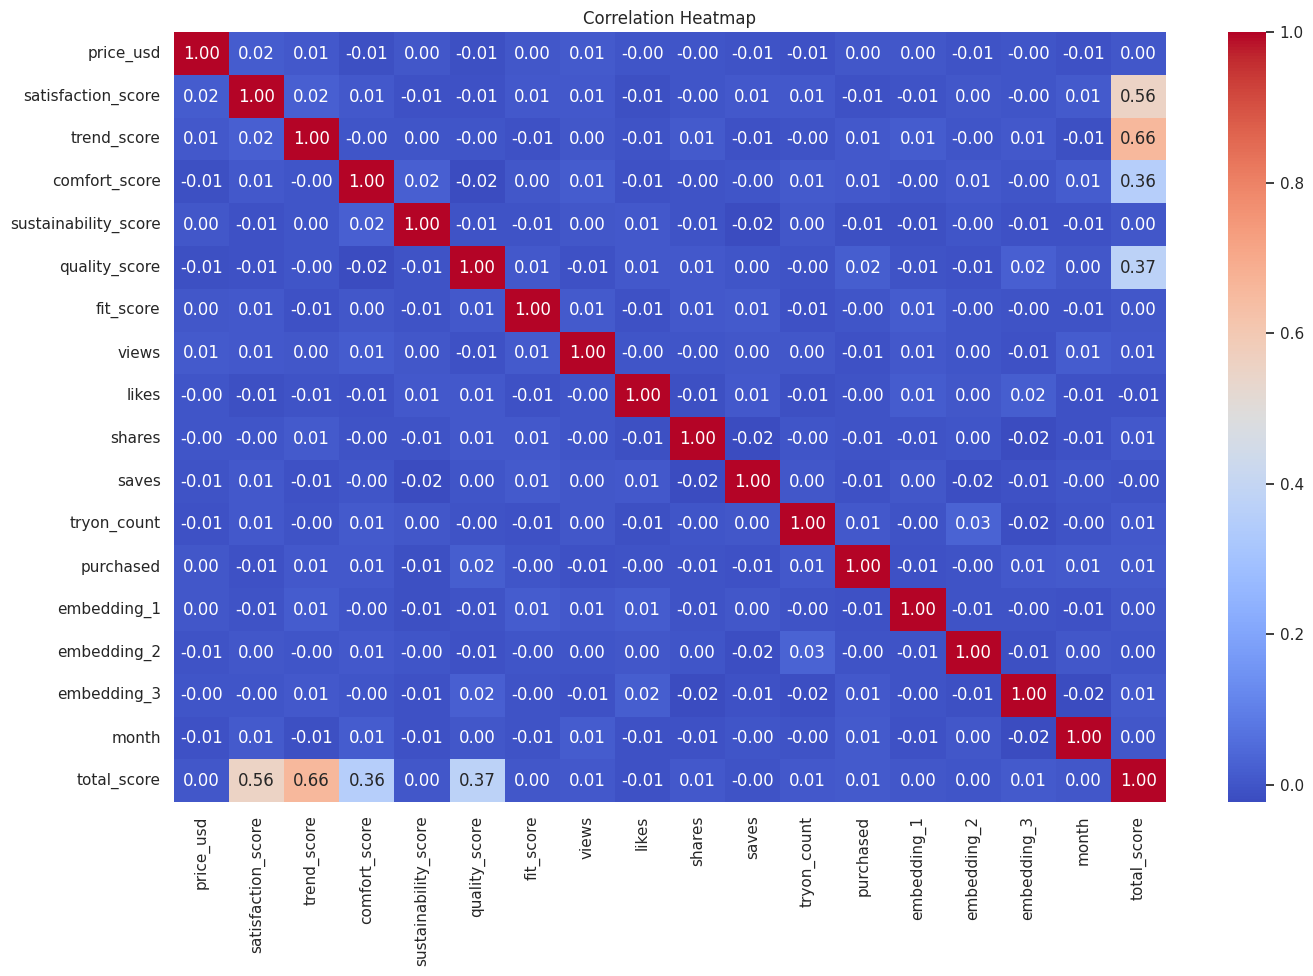

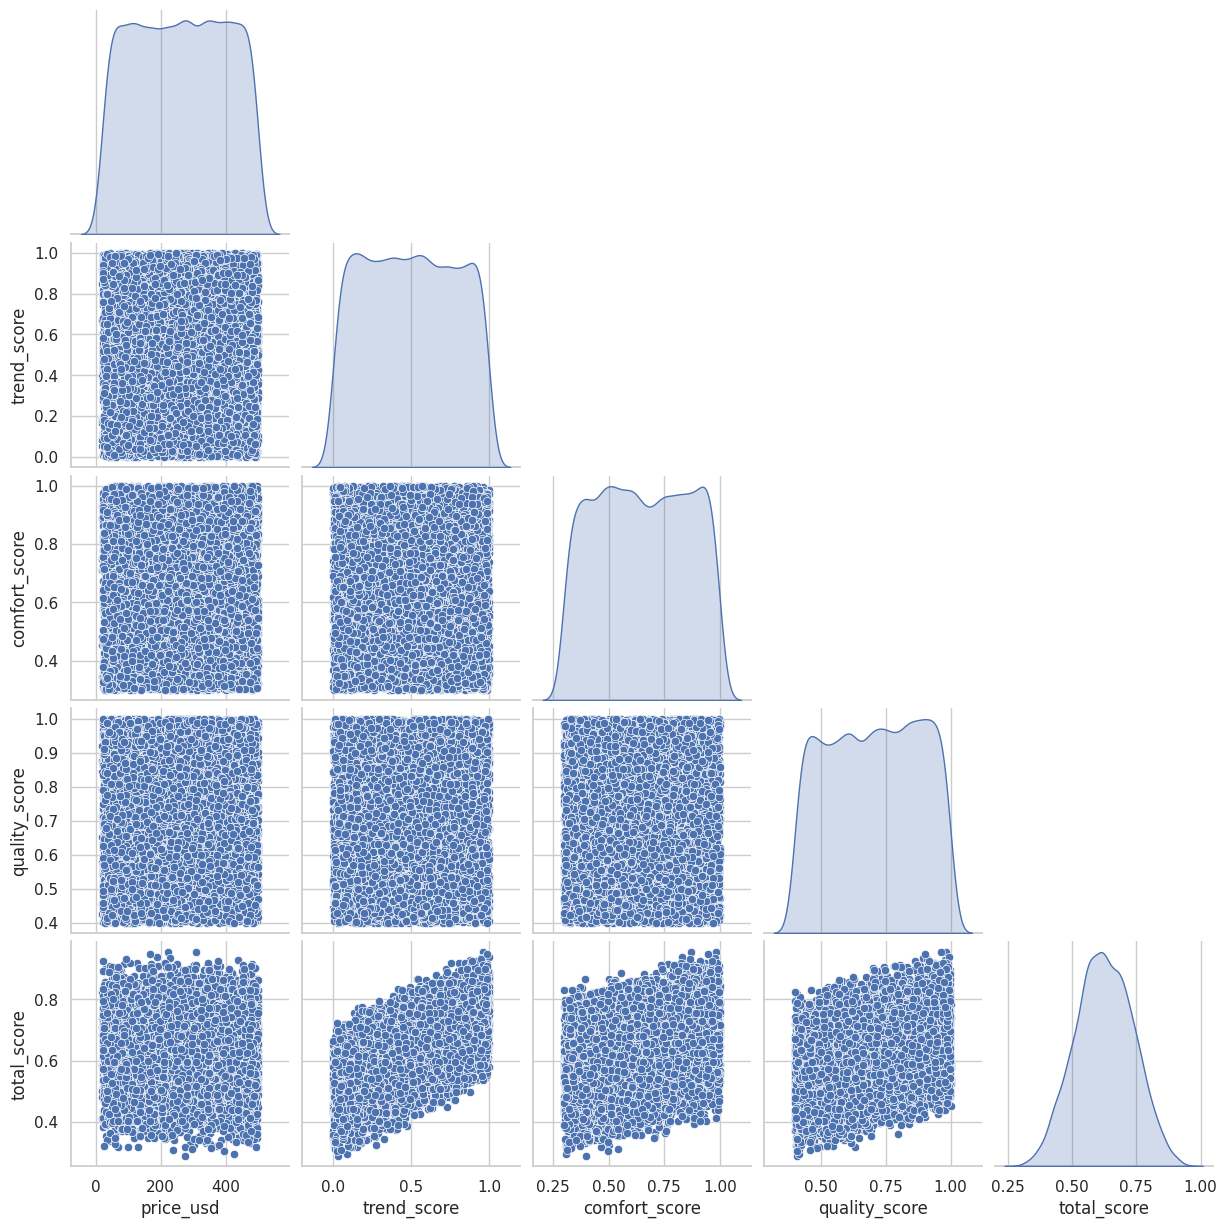

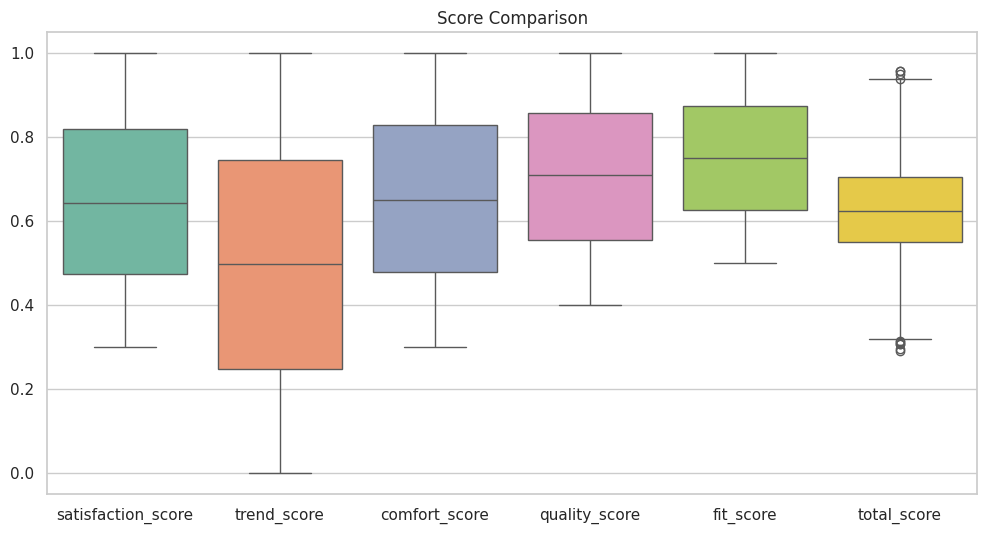

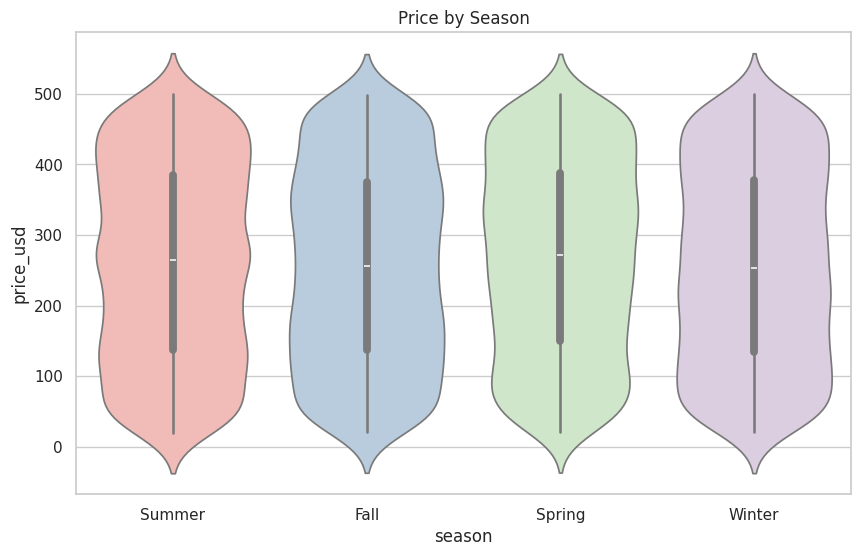

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# STYLE
# -------------------------------
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# -------------------------------
# 1. Gender Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='gender', hue='gender', palette='Set2', legend=False)
plt.title("Gender Distribution", fontsize=16)
plt.show()

# -------------------------------
# 2. Age Group Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='age_group', hue='age_group', palette='viridis', legend=False)
plt.title("Age Group Distribution")
plt.show()

# -------------------------------
# 3. Body Type Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='body_type', hue='body_type', palette='coolwarm', legend=False)
plt.title("Body Type Distribution")
plt.xticks(rotation=30)
plt.show()

# -------------------------------
# 4. Skin Tone Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='skin_tone', hue='skin_tone', palette='magma', legend=False)
plt.title("Skin Tone")
plt.show()

# -------------------------------
# 5. Clothing Type
# -------------------------------
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='clothing_type', hue='clothing_type', palette='tab20', legend=False)
plt.title("Clothing Type")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 6. Fabric Count
# -------------------------------
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='fabric', hue='fabric', palette='cubehelix', legend=False)
plt.title("Fabric Distribution")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 7. Preferred Brand
# -------------------------------
plt.figure(figsize=(12,5))
sns.countplot(
    data=df,
    x='preferred_brand',
    order=df['preferred_brand'].value_counts().index,
    hue='preferred_brand',
    palette='Spectral',
    legend=False
)
plt.xticks(rotation=45)
plt.title("Preferred Brand")
plt.show()

# -------------------------------
# 8. Primary Color
# -------------------------------
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='primary_color', hue='primary_color', palette='rainbow', legend=False)
plt.xticks(rotation=45)
plt.title("Primary Color Preference")
plt.show()

# -------------------------------
# 9. Pattern
# -------------------------------
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='pattern', hue='pattern', palette='Accent', legend=False)
plt.title("Pattern Distribution")
plt.show()

# -------------------------------
# 10. Occasion
# -------------------------------
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='occasion', hue='occasion', palette='Dark2', legend=False)
plt.title("Occasion")
plt.show()

# -------------------------------
# 11. Mood
# -------------------------------
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='mood', hue='mood', palette='Paired', legend=False)
plt.title("Mood Distribution")
plt.show()

# -------------------------------
# 12. Season
# -------------------------------
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='season', hue='season', palette='husl', legend=False)
plt.title("Season")
plt.show()

# -------------------------------
# 13. Weather
# -------------------------------
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='weather', hue='weather', palette='Set3', legend=False)
plt.title("Weather")
plt.show()

# -------------------------------
# 14. Price Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['price_usd'], bins=30, kde=True, color='orange')
plt.title("Price Distribution")
plt.show()

# -------------------------------
# 15. Budget vs Price
# -------------------------------
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='budget_level', y='price_usd', hue='budget_level', palette='cool', legend=False)
plt.title("Budget Level vs Price")
plt.show()

# -------------------------------
# 16. Satisfaction Score
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['satisfaction_score'], kde=True, color='green')
plt.title("Satisfaction Score")
plt.show()

# -------------------------------
# 17. Trend Score
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['trend_score'], kde=True, color='red')
plt.title("Trend Score")
plt.show()

# -------------------------------
# 18. Comfort Score
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['comfort_score'], kde=True, color='purple')
plt.title("Comfort Score")
plt.show()

# -------------------------------
# 19. Quality Score
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['quality_score'], kde=True, color='blue')
plt.title("Quality Score")
plt.show()

# -------------------------------
# 20. Total Score
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['total_score'], kde=True, color='brown')
plt.title("Total Score")
plt.show()

# -------------------------------
# 21. Purchased
# -------------------------------
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='purchased', hue='purchased', palette=['tomato','limegreen'], legend=False)
plt.title("Purchased")
plt.show()

# -------------------------------
# 22. Likes vs Views
# -------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='views', y='likes', hue='purchased', palette='Set1', s=100)
plt.title("Views vs Likes")
plt.show()

# -------------------------------
# 23. Shares vs Saves
# -------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='shares', y='saves', hue='season', palette='tab10', s=100)
plt.title("Shares vs Saves")
plt.show()

# -------------------------------
# 24. Try-On Count
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['tryon_count'], bins=20, color='teal')
plt.title("Try-On Count")
plt.show()

# -------------------------------
# 25. Recommendation Priority
# -------------------------------
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='recommendation_priority',
    hue='recommendation_priority',
    palette='RdYlGn',
    legend=False
)
plt.title("Recommendation Priority")
plt.show()

# -------------------------------
# 26. Monthly Purchases
# -------------------------------
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='month', hue='purchased', palette='viridis')
plt.title("Monthly Purchases")
plt.show()

# -------------------------------
# 27. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(16,10))
numeric = df.select_dtypes(include=np.number)
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 28. Pairplot
# -------------------------------
cols = [
    'price_usd',
    'trend_score',
    'comfort_score',
    'quality_score',
    'total_score'
]

sns.pairplot(df[cols], corner=True, diag_kind='kde')
plt.show()

# -------------------------------
# 29. Boxplot of Scores
# -------------------------------
scores = [
    'satisfaction_score',
    'trend_score',
    'comfort_score',
    'quality_score',
    'fit_score',
    'total_score'
]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[scores], palette='Set2')
plt.title("Score Comparison")
plt.show()

# -------------------------------
# 30. Violin Plot
# -------------------------------
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='season', y='price_usd', hue='season', palette='Pastel1', legend=False)
plt.title("Price by Season")
plt.show()

## Features Engineering

Logistic Regression
Accuracy : 99.05 %
Precision: 99.05 %
Recall   : 99.05 %
F1 Score : 99.04 %

Classification Report

              precision    recall  f1-score   support

        High       0.99      0.99      0.99      1092
      Medium       1.00      0.99      0.99       884
Top Priority       0.98      0.93      0.95       124

    accuracy                           0.99      2100
   macro avg       0.99      0.97      0.98      2100
weighted avg       0.99      0.99      0.99      2100



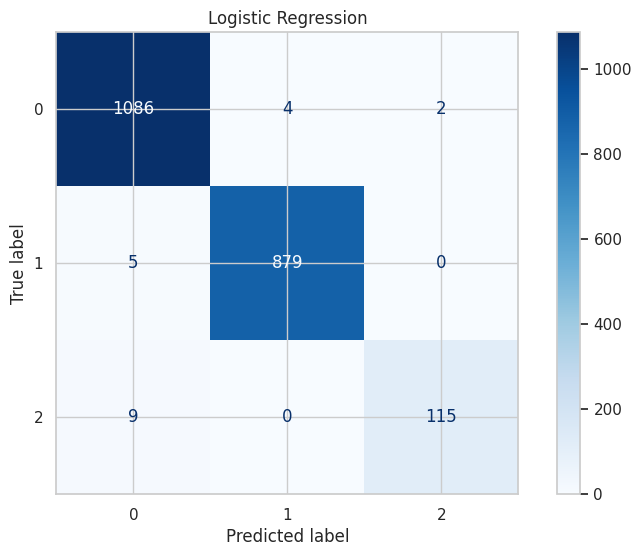

KNN
Accuracy : 71.14 %
Precision: 70.36 %
Recall   : 71.14 %
F1 Score : 69.1 %

Classification Report

              precision    recall  f1-score   support

        High       0.69      0.82      0.75      1092
      Medium       0.75      0.68      0.71       884
Top Priority       0.50      0.02      0.05       124

    accuracy                           0.71      2100
   macro avg       0.65      0.51      0.50      2100
weighted avg       0.70      0.71      0.69      2100



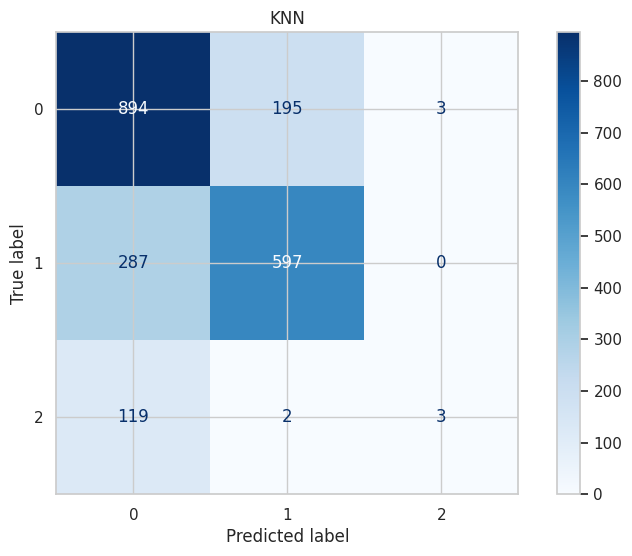

Decision Tree
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1 Score : 100.0 %

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1092
      Medium       1.00      1.00      1.00       884
Top Priority       1.00      1.00      1.00       124

    accuracy                           1.00      2100
   macro avg       1.00      1.00      1.00      2100
weighted avg       1.00      1.00      1.00      2100



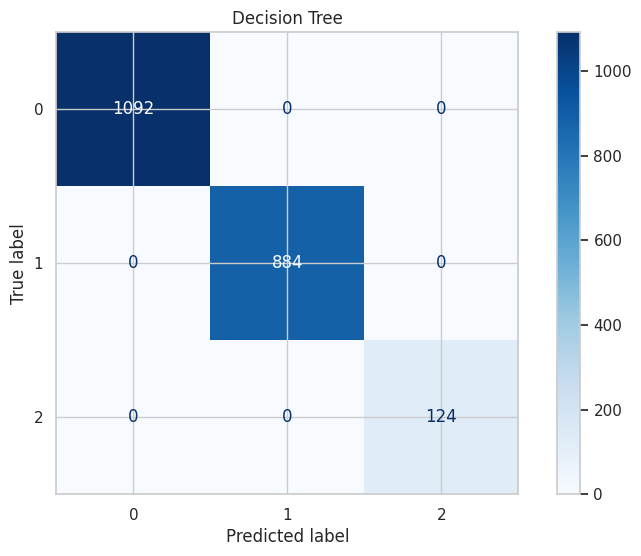

Random Forest
Accuracy : 99.95 %
Precision: 99.95 %
Recall   : 99.95 %
F1 Score : 99.95 %

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1092
      Medium       1.00      1.00      1.00       884
Top Priority       1.00      0.99      1.00       124

    accuracy                           1.00      2100
   macro avg       1.00      1.00      1.00      2100
weighted avg       1.00      1.00      1.00      2100



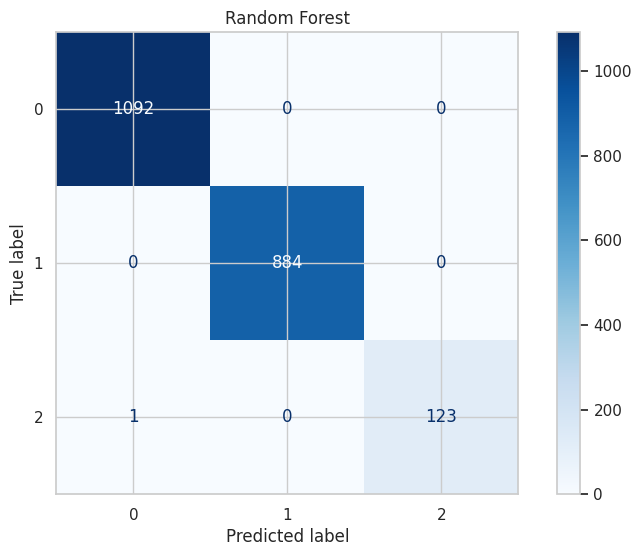

Naive Bayes
Accuracy : 97.14 %
Precision: 97.2 %
Recall   : 97.14 %
F1 Score : 97.16 %

Classification Report

              precision    recall  f1-score   support

        High       0.97      0.97      0.97      1092
      Medium       0.99      0.97      0.98       884
Top Priority       0.87      0.95      0.91       124

    accuracy                           0.97      2100
   macro avg       0.94      0.97      0.95      2100
weighted avg       0.97      0.97      0.97      2100



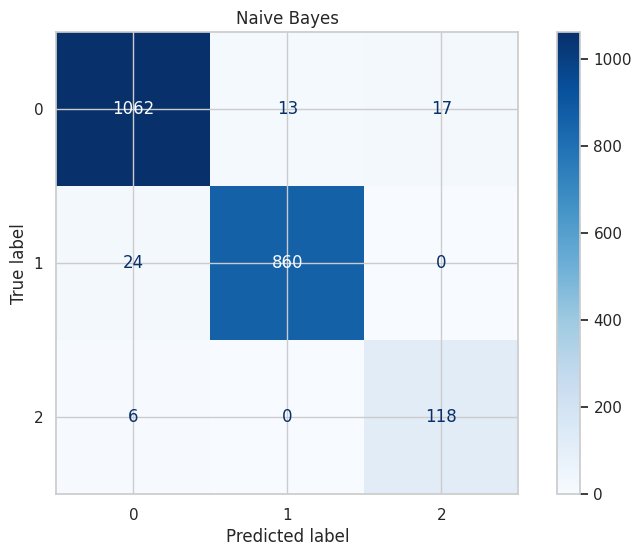

SVM
Accuracy : 95.33 %
Precision: 95.49 %
Recall   : 95.33 %
F1 Score : 95.06 %

Classification Report

              precision    recall  f1-score   support

        High       0.93      0.98      0.96      1092
      Medium       0.98      0.97      0.97       884
Top Priority       0.99      0.58      0.73       124

    accuracy                           0.95      2100
   macro avg       0.97      0.84      0.89      2100
weighted avg       0.95      0.95      0.95      2100



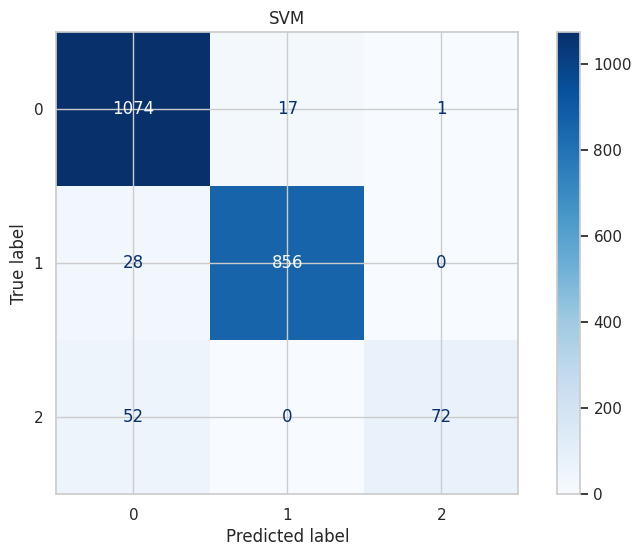



MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
2        Decision Tree  1.000000   1.000000  1.000000  1.000000
3        Random Forest  0.999524   0.999524  0.999524  0.999523
0  Logistic Regression  0.990476   0.990466  0.990476  0.990416
4          Naive Bayes  0.971429   0.972010  0.971429  0.971606
5                  SVM  0.953333   0.954945  0.953333  0.950644
1                  KNN  0.711429   0.703633  0.711429  0.690954


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

# ==========================================================
# REMOVE UNNECESSARY COLUMNS
# ==========================================================

drop_cols = [
    'user_id',
    'session_id',
    'timestamp',
    'outfit_description'
]

X = df.drop(columns=drop_cols + ['recommendation_priority'])

y = df['recommendation_priority']

# ==========================================================
# TRAIN TEST SPLIT (NO DATA LEAKAGE)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# NUMERIC & CATEGORICAL COLUMNS
# ==========================================================

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

cat_cols = X_train.select_dtypes(include='object').columns

# ==========================================================
# PREPROCESSING
# ==========================================================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(probability=True)
}

# ==========================================================
# TRAIN & EVALUATE
# ==========================================================

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    pre = precision_score(y_test, y_pred,
                          average='weighted')

    rec = recall_score(y_test, y_pred,
                       average='weighted')

    f1 = f1_score(y_test, y_pred,
                  average='weighted')

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", round(acc*100,2),"%")
    print("Precision:", round(pre*100,2),"%")
    print("Recall   :", round(rec*100,2),"%")
    print("F1 Score :", round(f1*100,2),"%")

    print("\nClassification Report\n")

    print(classification_report(y_test,y_pred))

    cm = confusion_matrix(y_test,y_pred)

    ConfusionMatrixDisplay(cm).plot(cmap='Blues')

    plt.title(name)

    plt.show()

    # --------------------------
    # ROC CURVE
    # --------------------------

    if len(np.unique(y)) == 2:

        y_prob = pipeline.predict_proba(X_test)[:,1]

        fpr,tpr,_ = roc_curve(y_test,y_prob)

        roc_auc = auc(fpr,tpr)

        plt.figure(figsize=(6,5))

        plt.plot(fpr,tpr,
                 label="AUC = %.3f"%roc_auc)

        plt.plot([0,1],[0,1],'--')

        plt.xlabel("False Positive Rate")

        plt.ylabel("True Positive Rate")

        plt.title(name+" ROC Curve")

        plt.legend()

        plt.show()

    results.append([name,acc,pre,rec,f1])

# ==========================================================
# COMPARISON TABLE
# ==========================================================

result = pd.DataFrame(results,
                      columns=[
                          'Model',
                          'Accuracy',
                          'Precision',
                          'Recall',
                          'F1 Score'
                      ])

result = result.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(result)

## Thanks......please upvote 